# barexam_qa — EDA

**Dataset:** `reglab/barexam_qa` (Zheng et al., CS&Law 2025)  
**Task:** Multiple-choice bar exam QA — given a fact pattern + question, pick A/B/C/D.  
**Size:** ~1,195 questions (train / validation / test)  
**Key columns:** `prompt`, `question`, `choice_a–d`, `answer`, `gold_passage`, `subject`, `source`

## 0. Load

In [ ]:
import os
import textwrap
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# Load cleaned data (run data_cleaning.ipynb first)
PARQUET = "./data/barexam_qa/barexam_qa_clean.parquet"
df = pd.read_parquet(PARQUET)

print(f"Shape : {df.shape}")
print(f"Cols  : {df.columns.tolist()}")

## 1. Overview

In [3]:
print("=== Split sizes ===")
print(df["split"].value_counts().to_string())
print()
print("=== Missing values ===")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "none")
print()
print("=== dtypes ===")
print(df.dtypes.to_string())


=== Split sizes ===
split
train         954
validation    124
test          117

=== Missing values ===
subject     601
prompt      750
question      1
choice_d      1

=== dtypes ===
idx                  str
dataset              str
example_id         int64
prompt_id          int64
source               str
subject              str
question_number    int64
prompt               str
question             str
choice_a             str
choice_b             str
choice_c             str
choice_d             str
answer               str
gold_passage         str
gold_idx             str
split                str


In [4]:
# Text length columns
df["prompt_len"]       = df["prompt"].str.len()
df["question_len"]     = df["question"].str.len()
df["query_len"]     = df["prompt"].str.len()+ df["question"].str.len()
df["gold_passage_len"] = df["gold_passage"].str.len()

df[["prompt_len", "question_len", "query_len", "gold_passage_len"]].describe().round(0)

,prompt_len,question_len,query_len,gold_passage_len
count,445.0,1194.0,445.0,1195.0
mean,802.0,532.0,1016.0,743.0
std,444.0,404.0,445.0,729.0
min,48.0,20.0,192.0,42.0
25%,424.0,194.0,664.0,362.0
50%,771.0,442.0,955.0,569.0
75%,1135.0,766.0,1347.0,910.0
max,1870.0,2144.0,2304.0,10998.0


## 2. Distributions

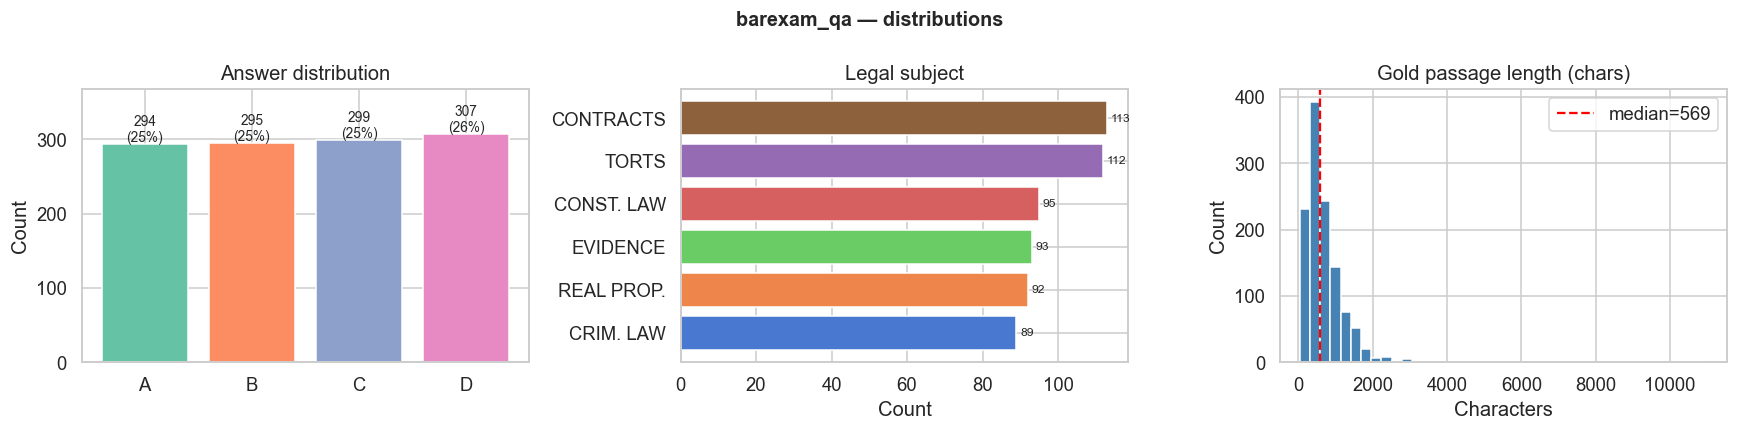

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("barexam_qa — distributions", fontsize=13, fontweight="bold")

# Answer A/B/C/D
ax = axes[0]
counts = df["answer"].str.upper().value_counts().sort_index()
ax.bar(counts.index, counts.values, color=sns.color_palette("Set2", 4), edgecolor="white")
ax.set_title("Answer distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, f"{v}\n({v/len(df):.0%})", ha="center", fontsize=9)
ax.set_ylim(0, counts.max() * 1.2)

# Subject
ax = axes[1]
subj = df["subject"].value_counts()
ax.barh(subj.index[::-1], subj.values[::-1], color=sns.color_palette("muted", len(subj)))
ax.set_title("Legal subject")
ax.set_xlabel("Count")
for i, v in enumerate(subj.values[::-1]):
    ax.text(v + 1, i, str(v), va="center", fontsize=8)

# Gold passage length
ax = axes[2]
ax.hist(df["gold_passage_len"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax.axvline(df["gold_passage_len"].median(), color="red", ls="--",
           label=f"median={df['gold_passage_len'].median():.0f}")
ax.set_title("Gold passage length (chars)")
ax.set_xlabel("Characters")
ax.set_ylabel("Count")
ax.legend()



plt.tight_layout()
plt.show()


In [5]:
# Source breakdown
print("Source distribution:")
print(df["source"].value_counts().to_string())

Source distribution:
source
1998                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

## 3. Qualitative inspection — queries, answers, gold passages

The most important part: reading actual examples to understand what the model needs to do.

In [6]:
def show_example(row, wrap=100):
    w = lambda s: textwrap.fill(str(s), wrap) if pd.notna(s) else "—"
    print("─" * wrap)
    print(f"IDX: {row['idx']}  |  Subject: {row['subject']}  |  Source: {row['source']}  |  Split: {row['split']}")
    print()
    if pd.notna(row["prompt"]) and str(row["prompt"]).strip():
        print("FACT PATTERN:")
        print(w(row["prompt"]))
        print()
    print("QUESTION:")
    print(w(row["question"]))
    print()
    for c in ["a", "b", "c", "d"]:
        marker = " ◄ CORRECT" if str(row["answer"]).strip().upper() == c.upper() else ""
        print(f"  ({c.upper()}) {row[f'choice_{c}']}{marker}")
    print()
    print("GOLD PASSAGE:")
    print(w(row["gold_passage"]))
    print()

# Show 5 random examples
for _, row in df.sample(5, random_state=42).iterrows():
    show_example(row)

────────────────────────────────────────────────────────────────────────────────────────────────────
IDX: mbe_809  |  Subject: CRIM. LAW  |  Source: 1991-July  |  Split: train

QUESTION:
Smith and Penn were charged with murder. Each gave a confession to the police that implicated both
of them. Smith later retracted her confession, claiming that it was coerced. Smith and Penn were
tried together. The prosecutor offered both confessions into evidence. Smith and Penn objected.
After a hearing, the trial judge found that both confessions were voluntary and admitted both into
evidence. Smith testified at trial. She denied any involvement in the crime and claimed that her
confession was false and the result of coercion. Both defendants were convicted. On appeal, Smith
contends her conviction should be reversed because of the admission into evidence of Penn's
confession. Smith's contention is

  (A) correct, unless Penn testified at trial. ◄ CORRECT
  (B) correct, whether or not Penn testifie

### 3a. One example per subject
Get a feel for how the question style varies across legal topics.

In [7]:
for subject, group in df.groupby("subject"):
    show_example(group.sample(1, random_state=0).iloc[0])

────────────────────────────────────────────────────────────────────────────────────────────────────
IDX: mbe_569  |  Subject: CONST. LAW  |  Source: 1991-Feb  |  Split: train

QUESTION:
Congressional hearings determined that the use of mechanical power hammers is very dangerous to the
persons using them and to persons in the vicinity of the persons using them. As a result, Congress
enacted a statute prohibiting the use of mechanical power hammers on all construction projects in
the United States. Subsequently, a study conducted by a private research firm concluded that nails
driven by mechanical power hammers have longer-lasting joining power than hand-driven nails. After
learning about this study, the city council of the city of Green enacted an amendment to its
building safety code requiring the use of mechanical power hammers in the construction of all
buildings intended for human habitation. This amendment to the city of Green's building safety code
is

  (A) unconstitutional, bec

### 3b. Gold passage length extremes
Shortest and longest gold passages — relevant for context window sizing.

In [8]:
print("=== 3 SHORTEST gold passages ===")
for _, row in df.nsmallest(3, "gold_passage_len").iterrows():
    show_example(row)

print("\n=== 3 LONGEST gold passages ===")
for _, row in df.nlargest(3, "gold_passage_len").iterrows():
    show_example(row)

=== 3 SHORTEST gold passages ===
────────────────────────────────────────────────────────────────────────────────────────────────────
IDX: mbe_499  |  Subject: nan  |  Source: MBE-1985-part7  |  Split: train

QUESTION:
Miller applied to the state liquor board for transfer of the license of Miller's Bar and Grill to a
new site. The board held a hearing on the application. At that hearing, Hammond appeared without
being subpoenaed and stated that Miller had underworld connections. Although Hammond did not know
this information to be true, he had heard rumors about Miller's character and had noticed several
underworld figures going in and out of Miller's Bar and Grill. In fact, Miller had no underworld
connections. In a claim against Hammond based on defamation, Miller will

  (A) not recover if Hammond reasonably believed his statement to be true ◄ CORRECT
  (B) not recover if the board granted Miller's application
  (C) recover, because Hammond's statement was false
  (D) recover, becau

### 3c. Cases where prompt is empty
Some questions have no fact pattern — standalone questions. How many?

Questions WITHOUT a fact pattern: 750 / 1195 (63%)


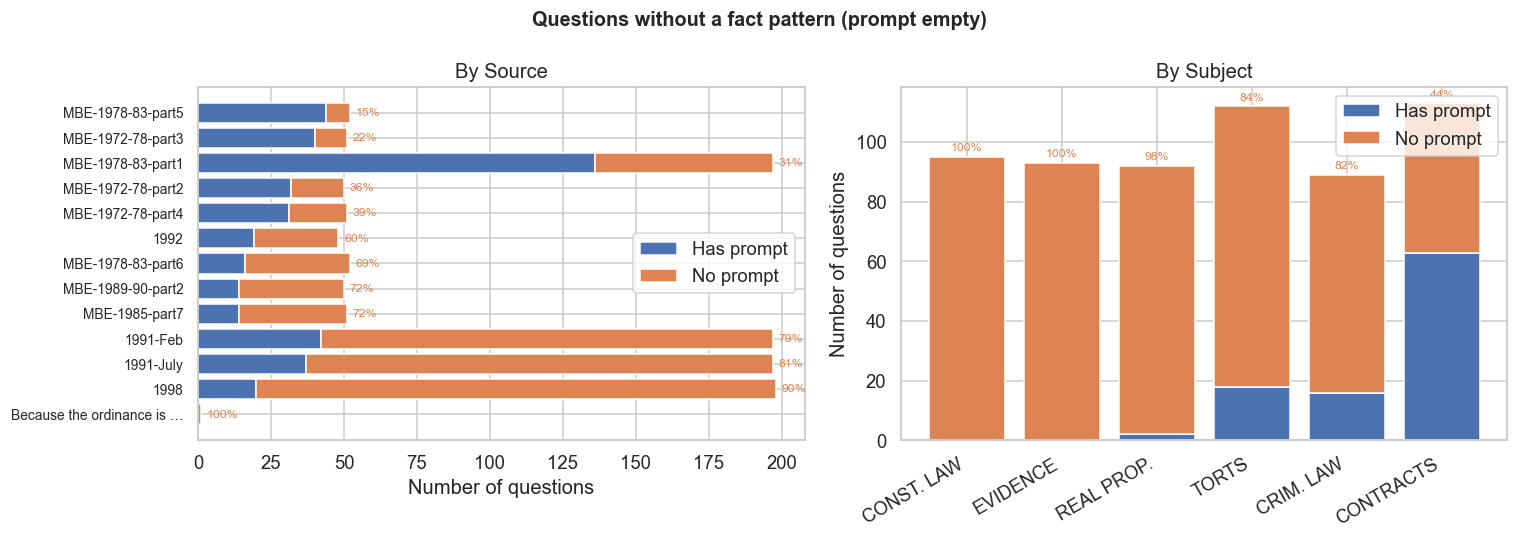


--- By SOURCE ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [9]:
import matplotlib.pyplot as plt

no_prompt = df[df["prompt"].isna() | (df["prompt"].str.strip() == "")]

print(f"Questions WITHOUT a fact pattern: {len(no_prompt)} / {len(df)} ({len(no_prompt)/len(df):.0%})")

def empty_prompt_stats(df, by):
    return (
        df.groupby(by)
        .agg(
            total=("prompt", "size"),  # counts all rows, including NaN
            no_prompt=("prompt", lambda s: (s.isna() | (s.str.strip() == "")).sum()),
        )
        .assign(
            has_prompt=lambda d: d["total"] - d["no_prompt"],
            pct_missing=lambda d: (d["no_prompt"] / d["total"] * 100).round(1)
        )
        .sort_values("pct_missing", ascending=False)
    )

def shorten_labels(labels, max_len=25):
    return [l[:max_len] + "…" if len(l) > max_len else l for l in labels]

src  = empty_prompt_stats(df, "source")
subj = empty_prompt_stats(df, "subject")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Questions without a fact pattern (prompt empty)", fontsize=13, fontweight="bold")

# --- By Source: horizontal bars ---
ax = axes[0]
y = range(len(src))
ax.barh(list(y), src["has_prompt"], label="Has prompt", color="#4c72b0")
ax.barh(list(y), src["no_prompt"], label="No prompt", color="#dd8452", left=src["has_prompt"])
ax.set_yticks(list(y))
ax.set_yticklabels(shorten_labels(src.index, max_len=25), fontsize=9)
ax.set_xlabel("Number of questions")
ax.set_title("By Source")
ax.legend()

for i, (_, row) in enumerate(src.iterrows()):
    if row["no_prompt"] > 0:
        ax.text(row["total"] + 2, i, f'{row["pct_missing"]:.0f}%', va="center", fontsize=8, color="#dd8452")

# --- By Subject: vertical bars ---
ax = axes[1]
x = range(len(subj))
ax.bar(list(x), subj["has_prompt"], label="Has prompt", color="#4c72b0")
ax.bar(list(x), subj["no_prompt"], label="No prompt", color="#dd8452", bottom=subj["has_prompt"])
ax.set_xticks(list(x))
ax.set_xticklabels(subj.index, rotation=30, ha="right")
ax.set_ylabel("Number of questions")
ax.set_title("By Subject")
ax.legend()

for i, (_, row) in enumerate(subj.iterrows()):
    if row["no_prompt"] > 0:
        ax.text(i, row["total"] + 2, f'{row["pct_missing"]:.0f}%', ha="center", fontsize=8, color="#dd8452")

plt.tight_layout()
plt.show()

print("\n--- By SOURCE ---")
print(src[["total", "no_prompt", "has_prompt", "pct_missing"]].to_string())

print("\n--- By SUBJECT ---")
print(subj[["total", "no_prompt", "has_prompt", "pct_missing"]].to_string())

## 4. Relevance of gold passage to question

Quick sanity check: does the gold passage actually contain keywords from the question?

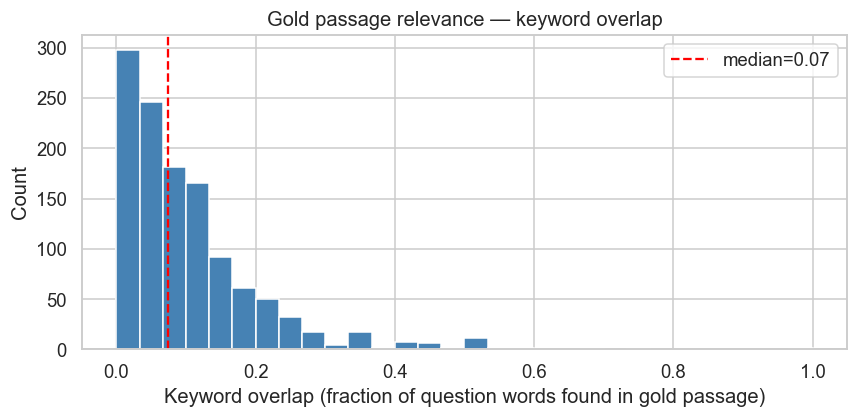

Mean overlap : 0.10
Low overlap (<0.3): 1142 examples


In [10]:
import re

def keyword_overlap(question, passage, min_len=5):
    """Fraction of question words (len >= min_len) found in the passage."""
    if pd.isna(question) or pd.isna(passage):
        return float("nan")
    q_words = set(w.lower() for w in re.findall(r"\b\w+\b", str(question)) if len(w) >= min_len)
    if not q_words:
        return float("nan")
    passage_lower = str(passage).lower()
    return sum(w in passage_lower for w in q_words) / len(q_words)

df["kw_overlap"] = df.apply(lambda r: keyword_overlap(r["question"], r["gold_passage"]), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["kw_overlap"].dropna(), bins=30, color="steelblue", edgecolor="white")
ax.axvline(df["kw_overlap"].median(), color="red", ls="--",
           label=f"median={df['kw_overlap'].median():.2f}")
ax.set_xlabel("Keyword overlap (fraction of question words found in gold passage)")
ax.set_ylabel("Count")
ax.set_title("Gold passage relevance — keyword overlap")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean overlap : {df['kw_overlap'].mean():.2f}")
print(f"Low overlap (<0.3): {(df['kw_overlap'] < 0.3).sum()} examples")

In [11]:
# Inspect low-overlap examples — cases where the gold passage seems loosely related
print("=== Examples with LOW keyword overlap (<0.2) ===")
for _, row in df[df["kw_overlap"] < 0.2].head(3).iterrows():
    show_example(row)

=== Examples with LOW keyword overlap (<0.2) ===
────────────────────────────────────────────────────────────────────────────────────────────────────
IDX: mbe_1  |  Subject: nan  |  Source: MBE-1972-78-part2  |  Split: train

FACT PATTERN:
Paul, the Plaintiff in a personal injury action, called Wes as a witness to testify that Dan's car,
in which Paul had been riding. ran a red light. Wes, however, testified that Dan's car did not run
the light.

QUESTION:
On cross-examination of Vic, Dan's attorney asked if Vic was drunk at the time he witnessed the
accident. and Vic responded, "No I have never in my life been drunk." Dan's attorney then sought to
prove by Yank that Vic was drunk on New Year's Eve two years before the accident. The trialjudge
should rule that Yank's testimony is

  (A) admissible to impeach Vic by showing that he had an imperfect recollection of recent events
  (B) admissible to show that Vic is not the kind of person on whom one should rely for ascertaining the truth

## 5. Summary

| Metric | Value |
|---|---|
| Total questions | ~1,195 |
| Splits | train / validation / test |
| Answer balance | roughly uniform across A/B/C/D |
| Legal subjects | 7 MBE categories (Torts, Contracts, ConLaw, …) |
| Fact pattern present | most questions; some standalone |
| Gold passage length | median ~500 chars; some very long |
| All columns flat | no nested structures — parquet is clean |

**For the RAG pipeline:**  
- Input = `prompt` + `question` + `choice_a–d`  
- Gold retrieval target = `gold_passage` (what a retriever should surface)  
- Downstream label = `answer` (A/B/C/D)